# Why insurance works

[Open in Colab](https://colab.research.google.com/github/andreasmang/stan/blob/main/demos/insurance.ipynb) &nbsp;·&nbsp; nothing to install &nbsp;·&nbsp; **Runtime > Run all** takes a few seconds

An insurer sells home policies. In a given year a policy has a 1% chance of a claim, and a
claim costs \$20,000 on average. So a policy is expected to cost \$200 --- but its standard
deviation is \$2,441, twelve times that. Almost every year it costs nothing, and
occasionally it costs a fortune.

How can a company sell a promise that unpredictable? Two theorems from this course, and one
warning.

In [1]:
import numpy as np, matplotlib.pyplot as plt
from statistics import NormalDist

rng = np.random.default_rng(2026)
p, mean_claim = 0.01, 20_000
claim = lambda k: rng.gamma(2.0, mean_claim / 2.0, k)      # claim sizes, mean 20,000

mu = p * mean_claim                                        # 200, the expected loss
sigma = np.sqrt(p * (2 * (mean_claim/2)**2 + mean_claim**2) - mu**2)
z = NormalDist().inv_cdf(0.995)                            # the 1-in-200 year: 2.576

def year_losses(n, years, p_year):
    # total claims paid per year: Binomial(n, p_year) claims, each a draw from `claim`
    N = rng.binomial(n, p_year)
    return np.bincount(np.repeat(np.arange(years), N), weights=claim(N.sum()), minlength=years)

print(f"one policy:  expected loss ${mu:,.0f}   standard deviation ${sigma:,.0f}")

one policy:  expected loss $200   standard deviation $2,441


## 1. The law of large numbers: a premium can be set

Watch the average loss per policy as an insurer writes more policies. Three insurers,
100,000 policies each.

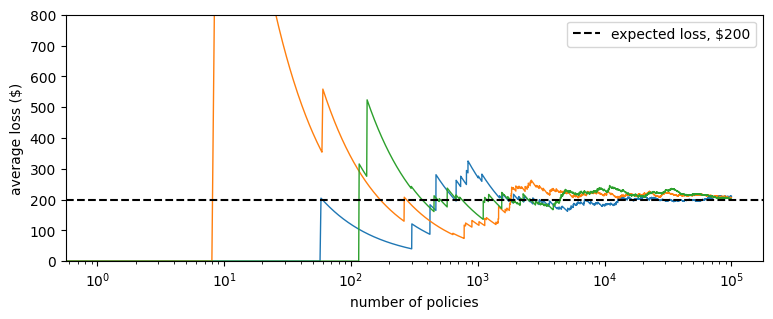

In [2]:
plt.figure(figsize=(9, 3.2))
for _ in range(3):
    loss = np.where(rng.random(100_000) < p, claim(100_000), 0.0)
    plt.plot(np.cumsum(loss) / np.arange(1, 100_001), lw=1)
plt.axhline(mu, color="k", ls="--", label="expected loss, $200")
plt.xscale("log"); plt.ylim(0, 800); plt.xlabel("number of policies"); plt.ylabel("average loss ($)")
plt.legend(); plt.show()

One policy is a lottery. The average over many is not: by ten thousand policies it sits on
\$200. **That is what makes a premium possible** --- not predicting any one customer, but
knowing the average.

## 2. The central limit theorem: how much capital to hold

A bad year is paid out of capital. European regulation asks an insurer to survive a
1-in-200 year, so it needs to cover the 99.5% point of the loss distribution. The CLT says
the average loss is roughly $\mathcal{N}(\mu, \sigma^2/n)$, so the capital needed per policy
is about $2.576\,\sigma/\sqrt{n}$.

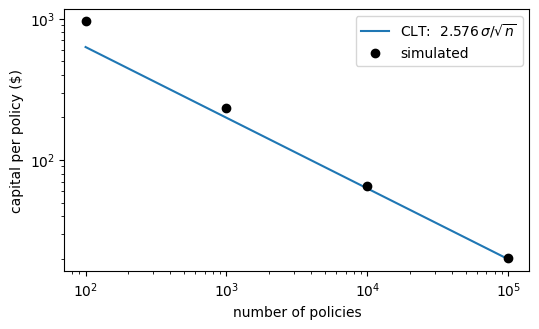

    100 policies:  $   957 of capital per policy
  1,000 policies:  $   233 of capital per policy
 10,000 policies:  $    66 of capital per policy
100,000 policies:  $    20 of capital per policy


In [3]:
sizes = [100, 1_000, 10_000, 100_000]
need = [np.quantile(year_losses(n, 100_000, np.full(100_000, p)) / n - mu, 0.995) for n in sizes]

plt.figure(figsize=(6, 3.4))
grid = np.logspace(2, 5, 40)
plt.loglog(grid, z * sigma / np.sqrt(grid), label=r"CLT:  $2.576\,\sigma/\sqrt{n}$")
plt.loglog(sizes, need, "ko", label="simulated")
plt.xlabel("number of policies"); plt.ylabel("capital per policy ($)"); plt.legend(); plt.show()

for n, c in zip(sizes, need):
    print(f"{n:>7,} policies:  ${c:>6.0f} of capital per policy")

Capital per policy falls like $1/\sqrt{n}$: a hundred times more policies needs ten times
less capital *each*. (The dot at 100 policies sits above the line because one claim a year
is too little to average; by 10,000 the two agree.) A small insurer must hold several times the premium in reserve; a large
one holds a fraction of it. **That is why insurance is a business of large companies**, and
it is nothing but $\sigma/\sqrt{n}$.

## 3. The warning: risks that move together

Both theorems assume the policies are independent. Add a hurricane: one year in fifty, every
policyholder's chance of a claim jumps to 10%. In calm years it is a little under 1%, chosen
so that **each policy on its own is exactly as before** --- same 1% chance, same claim sizes,
same \$200 expected loss. Only their independence is gone.

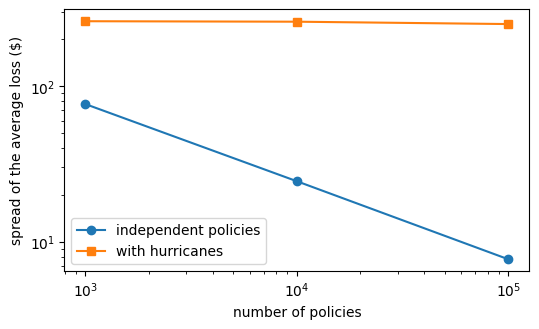

at 100,000 policies:  independent $8,  with hurricanes $251


In [4]:
q, p_storm = 0.02, 0.10
p_calm = (p - q * p_storm) / (1 - q)                       # keeps each policy's rate at 1%

sizes = [1_000, 10_000, 100_000]
indep = [np.std(year_losses(n, 40_000, np.full(40_000, p)) / n) for n in sizes]
storm = [np.std(year_losses(n, 40_000, np.where(rng.random(40_000) < q, p_storm, p_calm)) / n)
         for n in sizes]

plt.figure(figsize=(6, 3.4))
plt.loglog(sizes, indep, "o-", label="independent policies")
plt.loglog(sizes, storm, "s-", label="with hurricanes")
plt.xlabel("number of policies"); plt.ylabel("spread of the average loss ($)")
plt.legend(); plt.show()

print(f"at 100,000 policies:  independent ${indep[-1]:.0f},  with hurricanes ${storm[-1]:.0f}")

With independent policies the spread keeps shrinking. With hurricanes it **stops at about
\$250 per policy** --- more than the expected loss itself --- and no number of policies brings
it lower.

The reason is one line of algebra. The proof of the law of large numbers uses
$\operatorname{Var}(\overline{X}_n) = \sigma^2/n$, and that step needs independence. In
general

$$\operatorname{Var}(\overline{X}_n) = \frac{\sigma^{2}}{n} + \Bigl(1 - \frac1n\Bigr)\operatorname{Cov}(X_i, X_j),$$

so with positive correlation the variance does not go to $0$; it goes to the covariance.
**A risk everyone shares cannot be pooled away.** An insurer who sized its capital by the
formula in Section 2 would be using a spread thirty times too small at 100,000 policies, and
the bigger the insurer the worse the error, because that formula promises safety in size.

Hurricane Andrew in 1992 produced insured losses far beyond what the industry held in
reserve, and several Florida insurers failed.

---

This notebook is part of [STAN](https://github.com/andreasmang/stan), the code repository
for MATH 166 (Statistics) at Tufts University. The independence assumption is Section 1.5 of
the lecture notes.